In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = '/content/drive/MyDrive/PJME/PJME_hourly.csv'

df = pd.read_csv(path)

In [3]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [14]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(145366, 2)
Index(['PJME_MW', 'scaled'], dtype='object')
PJME_MW    0
scaled     0
dtype: int64


In [16]:
import matplotlib.pyplot as plt

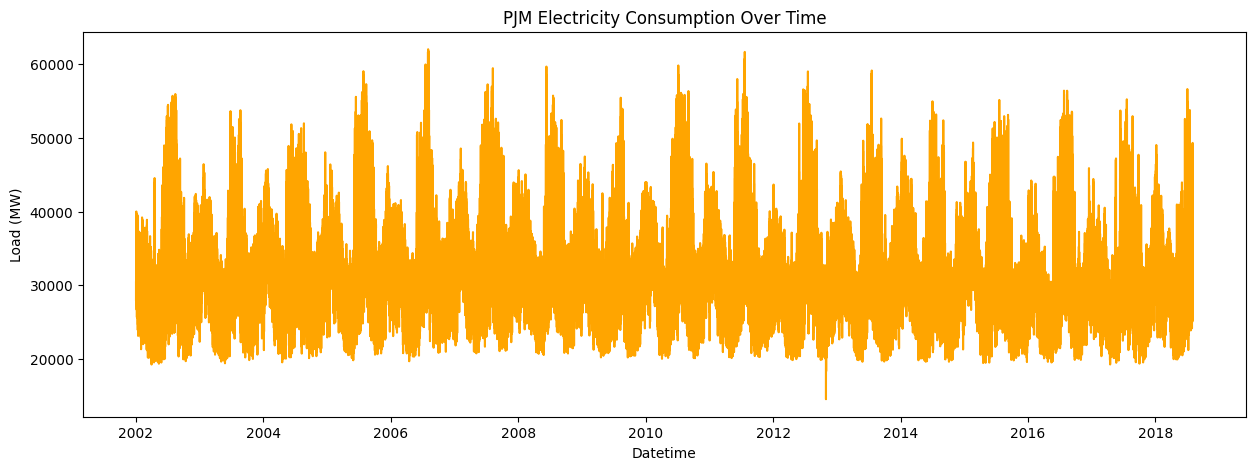

In [19]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['PJME_MW'],color="orange")
plt.title('PJM Electricity Consumption Over Time')
plt.xlabel('Datetime')
plt.ylabel('Load (MW)')
plt.show()

In [20]:
data = df[['PJME_MW']].copy()
data.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data['scaled_load'] = scaler.fit_transform(data[['PJME_MW']])

data.head()

,PJME_MW,scaled_load
Datetime,,
2002-01-01 01:00:00,30393.0,0.333909
2002-01-01 02:00:00,29265.0,0.310144
2002-01-01 03:00:00,28357.0,0.291014
2002-01-01 04:00:00,27899.0,0.281365
2002-01-01 05:00:00,28057.0,0.284694


In [22]:
def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])

    return np.array(X), np.array(y)

In [23]:
seq_length = 24

series = data['scaled_load'].values

X, y = create_sequences(series, seq_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (145342, 24)
y shape: (145342,)


In [24]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print("Reshaped X shape:", X.shape)

Reshaped X shape: (145342, 24, 1)


In [25]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (116273, 24, 1)
X_test : (29069, 24, 1)
y_train: (116273,)
y_test : (29069,)


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 5.3005e-04 - val_loss: 9.0271e-05
Epoch 2/5
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 1.2177e-04 - val_loss: 1.1940e-04
Epoch 3/5
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 1.1979e-04 - val_loss: 8.7790e-05
Epoch 4/5
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 1.2078e-04 - val_loss: 7.8405e-05
Epoch 5/5
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 1.1919e-04 - val_loss: 7.7213e-05


In [28]:
predictions = model.predict(X_test)
print(predictions[:5])

909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
[[0.39142364]
 [0.40436625]
 [0.37181628]
 [0.32990634]
 [0.28322017]]


In [29]:
predictions_actual = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

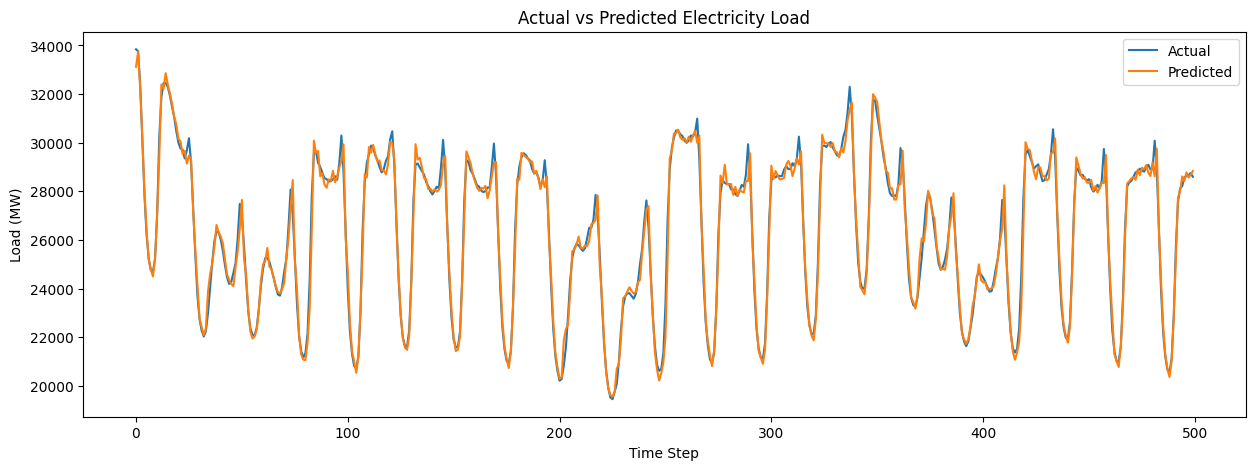

In [30]:
plt.figure(figsize=(15,5))
plt.plot(y_test_actual[:500], label='Actual')
plt.plot(predictions_actual[:500], label='Predicted')
plt.title('Actual vs Predicted Electricity Load')
plt.xlabel('Time Step')
plt.ylabel('Load (MW)')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(y_test_actual, predictions_actual))
print("RMSE:", rmse)

RMSE: 417.080287122428
